<a href="https://colab.research.google.com/github/ramirezcarlos292/miaad_python_programming/blob/main/practices/Pr%C3%A1ctica_21_Ejercicios_con_EDA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# # Práctica 21 Ejercicios con EDA 2



---



Alumno: Carlos Iván Ramírez Martínez <br>
Matricula: 260499 <br>
Email: al260499@alumnos.uacj.mx <br>


---

# Objetivo
Utiliza el conjunto de datos "Haberman's Survival" disponible en el siguiente 'https://archive.ics.uci.edu/ml/machine-learning-databases/haberman/haberman.data"'. Este conjunto contiene datos de pacientes con cáncer de mama, incluyendo edad, año de operación, número de ganglios axilares y estado de supervivencia (categórico). El conjunto de datos tiene valores faltantes.

Puedes emplear este código para cargar tu conjunto de datos

- url = "https://archive.ics.uci.edu/ml/machine-learning-databases/haberman/haberman.data"
- column_names = ['age', 'year', 'nodes', 'status']
- data = pd.read_csv(url, header=None, names=column_names

# Instrucciones para los estudiantes:

1. Descargar el archivo haberman.data desde el enlace proporcionado.
2. Realizar un EDA completo, incluyendo:
    * Descripción de los datos.
    * Histogramas para las columnas numéricas.
    * Gráficas de barras para la columna categórica status (supervivencia).
    * Boxplots para identificar outliers en las columnas numéricas.
    * Matriz de correlación y mapa de calor.
    * Pairplot para visualizar relaciones entre variables numéricas.
    * Pruebas de normalidad (Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov) y QQplot para las columnas numéricas.
3. Identificar y tratar los datos faltantes utilizando técnicas como imputación por media, mediana o moda.
4. Repetir el EDA después del tratamiento de datos faltantes y comparar los resultados

5. **Responde a estas preguntas y sube tus conclusiones a un PDF (se verificará el uso de IA).**

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
from scipy.stats import shapiro, anderson, kstest, probplot
from scipy import stats

# Conjunto de datos
https://archive.ics.uci.edu/dataset/43/haberman+s+survival

In [40]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/haberman/haberman.data"
column_names = ['age', 'year', 'nodes', 'status']
df = pd.read_csv(url, header=None, names=column_names)

df.head()

,age,year,nodes,status
0,30,64,1,1
1,30,62,3,1
2,30,65,0,1
3,31,59,2,1
4,31,65,4,1


In [41]:
print("Estadisticas descriptivas")
df.describe()

Estadisticas descriptivas


,age,year,nodes,status
count,306.000000,306.000000,306.000000,306.000000
mean,52.457516,62.852941,4.026144,1.264706
std,10.803452,3.249405,7.189654,0.441899
min,30.000000,58.000000,0.000000,1.000000
25%,44.000000,60.000000,0.000000,1.000000
50%,52.000000,63.000000,1.000000,1.000000
75%,60.750000,65.750000,4.000000,2.000000
max,83.000000,69.000000,52.000000,2.000000


In [42]:
for col in df.columns:
  print(f"La media de columna {col} es: {df[col].mean()}")
  print(f"La mediana de columna {col} es: {df[col].median()}")
  print(f"La moda de columna {col} es: {df[col].mode().iloc[0]}\n")

La media de columna age es: 52.45751633986928
La mediana de columna age es: 52.0
La moda de columna age es: 52

La media de columna year es: 62.85294117647059
La mediana de columna year es: 63.0
La moda de columna year es: 58

La media de columna nodes es: 4.026143790849673
La mediana de columna nodes es: 1.0
La moda de columna nodes es: 0

La media de columna status es: 1.2647058823529411
La mediana de columna status es: 1.0
La moda de columna status es: 1



### Análisis de cada variable
📌Age:
* Media: 52.45 años
* Mediana: 52 años
* Moda: 52 años
* mínimo-máximo: 30 - 83 años
* **Interpretación:** Para la variable Age, existe un valor atípico de 83 años, lo que podría estar sesgando la media 0.45 años. En sí la edad se centra alrededor de 52 años como indica la moda y la mediana.

📌Year:
* Media: Año 1962.85
* Mediana: Año 1963
* Moda: Año 1958
* mínimo-máximo: Año 1958 - 1969
* **Interpretación:** Para la variable Year, la moda nos indica que 1958 fue un año con mas cirugías, que el resto de años, pero no fue por mucho, ya que la media y la mediana nos llevan hacia los años 1962.85 y 1963, mientras si usamos la media y la desviacion estándar, nos llevaría a pensar en una distribución más uniforme.

📌Nodes:
* Media: 4.02
* Mediana: 1.0
* Moda: 1.0
* mínimo-máximo: 0 - 52
* **Interpretación:** Para la variable Nodes, la mediana y la moda indican 1 nodo, mientras que la media se encuentra sesgada por al menos el valor maximo,  que fue de 52 nodos, este último podría ser de un paciente cuyo cáncer fue incurable y en estado avanzado, este dato atípico podría ser el causante del sesgo en la media.

📌Status:
* Media: 1.26
* Mediana: 1.0
* Moda: 1.0
* mínimo-máximo: 1 - 2
* **Interpretación:** Para la variable Status, la mediana y la moda indican 1 nodo, mientras que la media se encuentra sesgada por el valor máximo que es de 2, esta columna al ser la variable categorica a predecir, sólo indica que hubo mas pacientes que sobrevivieron 5 años o mas que aquellos que murieron dentro de los 5 años posteriores a la cirugía.

In [43]:
# tenemos 306 registros en cuatro categorías númericas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     306 non-null    int64
 1   year    306 non-null    int64
 2   nodes   306 non-null    int64
 3   status  306 non-null    int64
dtypes: int64(4)
memory usage: 9.7 KB


In [44]:
# conjunto de datos no tiene valores faltantes
df.isnull().sum()

,0
age,0
year,0
nodes,0
status,0


In [45]:
df['status'].unique()

array([1, 2])

# 1. Análisis Exploratorio de Datos (EDA):

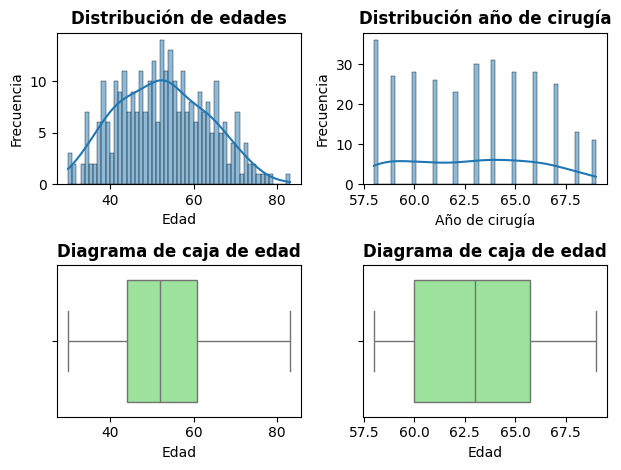

In [46]:
minn = df['age'].min()
maxx = df['age'].max()
fig, axs = plt.subplots(2, 2)
sns.histplot(df['age'], bins=maxx-minn, kde=True, ax=axs[0, 0])
axs[0, 0].set_title('Distribución de edades', fontweight='bold')
axs[0, 0].set_xlabel('Edad')
axs[0, 0].set_ylabel('Frecuencia')

sns.histplot(df['year'], bins=maxx-minn, kde=True, ax=axs[0, 1])
axs[0, 1].set_title('Distribución año de cirugía', fontweight='bold')
axs[0, 1].set_xlabel('Año de cirugía')
axs[0, 1].set_ylabel('Frecuencia')

sns.boxplot(df['age'], color='lightgreen', orient='h', ax=axs[1, 0])
axs[1, 0].set_title('Diagrama de caja de edad', fontweight='bold')
axs[1, 0].set_xlabel('Edad')

sns.boxplot(df['year'], color='lightgreen', orient='h', ax=axs[1, 1])
axs[1, 1].set_title('Diagrama de caja de edad', fontweight='bold')
axs[1, 1].set_xlabel('Edad')

plt.tight_layout()
plt.show()

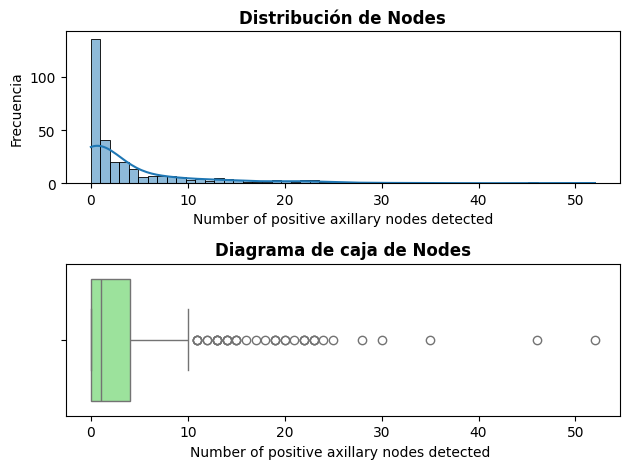

In [47]:
minn = df['age'].min()
maxx = df['age'].max()
fig, axs = plt.subplots(2, 1)
sns.histplot(df['nodes'], bins=maxx-minn, kde=True, ax=axs[0])
axs[0].set_title('Distribución de Nodes', fontweight='bold')
axs[0].set_xlabel('Number of positive axillary nodes detected')
axs[0].set_ylabel('Frecuencia')

sns.boxplot(df['nodes'], color='lightgreen', orient='h', ax=axs[1])
axs[1].set_title('Diagrama de caja de Nodes', fontweight='bold')
axs[1].set_xlabel('Number of positive axillary nodes detected ')

plt.tight_layout()
plt.show()

In [48]:
df_status_count = df['status'].value_counts().reset_index()
print(f"Percentage survived: {225/(225+81):.3f}%")
print(f"Percentage not survived: {81/(225+81):.3f}%")
df_status_count

Percentage survived: 0.735%
Percentage not survived: 0.265%


,status,count
0,1,225
1,2,81


Text(0.5, 1.0, 'Sobrevivientes')

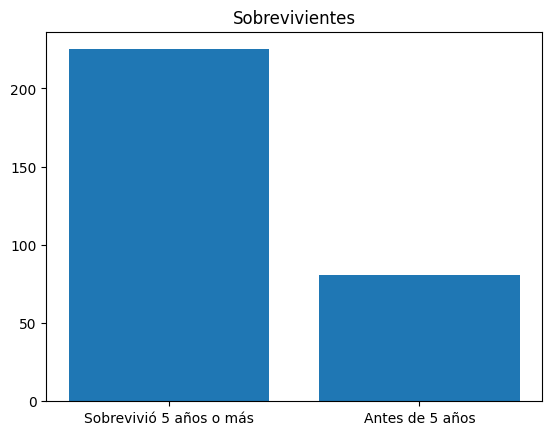

In [49]:
df_status_count['status'] = df_status_count['status'].map({1: 'Sobrevivió 5 años o más', 2:'Antes de 5 años'})
plt.bar(df_status_count['status'], height=df_status_count['count'])
plt.title('Sobrevivientes')

  * ¿Qué información relevante obtuviste de los histogramas y gráficas de densidad (PDF)?
    * *La variable 'age', asemeja una distribución normal, con algo de kurtosis.*
    * *La variable 'year', es una distribución uniforme lo que tiene sentido dado que el año en que fue realizada una cirugía podría no tener gran impacto en la supervivencia del paciente.*
    * *La variable 'nodes' en cambio tiene una distribución que parecería normal, salvo que esta cargada hacia la izquierda con una gran cola hacia la derecha, y alrededor de 30 valores atípicos.*
  * ¿Alguna variable parece seguir una distribución normal?
    * **Sí, la variable 'age' y 'nodes'.*
  * ¿Qué insights obtuviste de las gráficas de barras para la variable categórica status?
    * **La variable 'status', un 0.735% de los pacientes sobrevivieron 5 años o más despues de su cirugía, mientras que el 0.265% de pacientes falleció antes de 5 años después de su cirugía.
  * ¿Cómo se distribuyen los pacientes según su estado de supervivencia?

# 2. Pruebas de Normalidad:

age


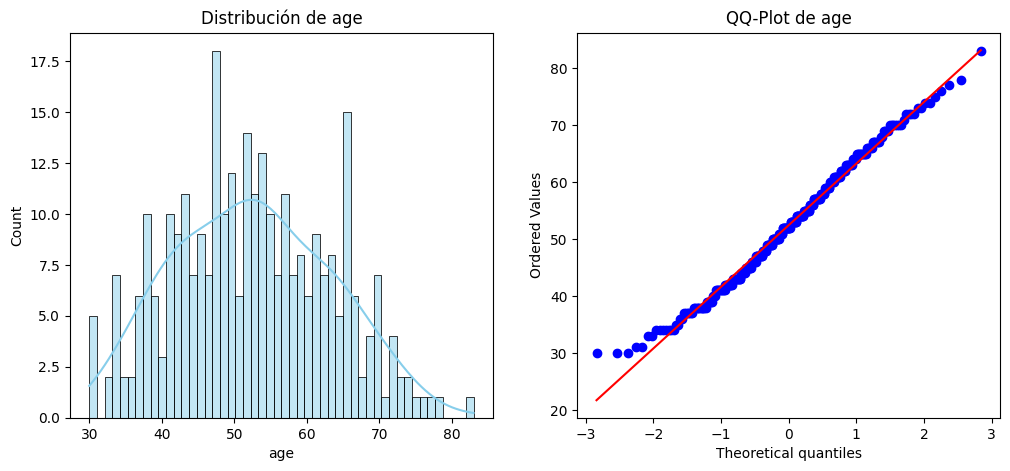


Pruebas de normalidad para la columna: age
Shapiro-Wilk Test: p-valor = 0.02605
Kolmogorov-Smirnov Test: p-valor = 0.46980
Anderson-Darling Test: Estadístico = 0.73156
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos parecen normales.
  Al nivel de significancia 2.5%, los datos parecen normales.
  Al nivel de significancia 1.0%, los datos parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00780
year


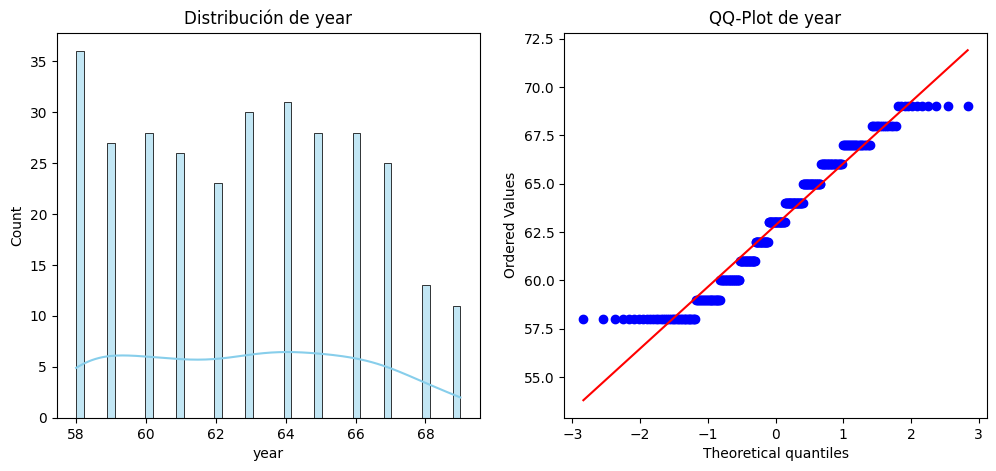


Pruebas de normalidad para la columna: year
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00158
Anderson-Darling Test: Estadístico = 4.31374
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
nodes


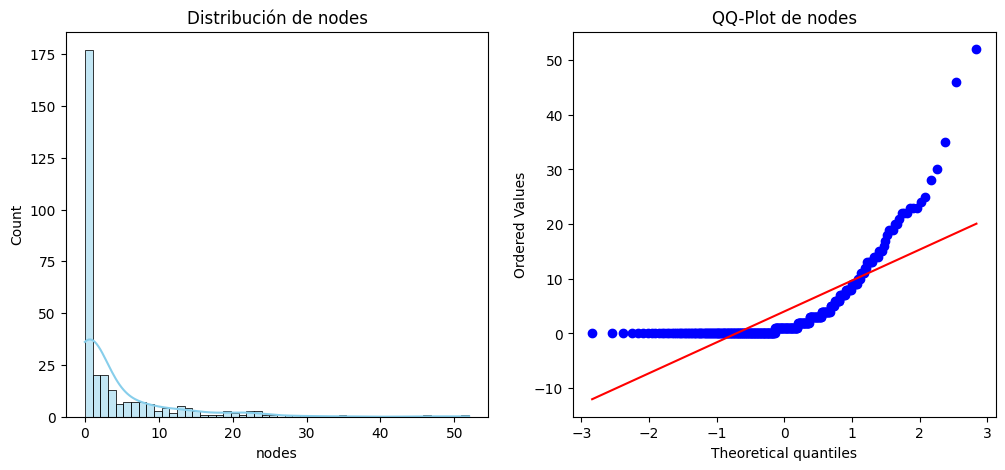


Pruebas de normalidad para la columna: nodes
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 39.68662
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
status


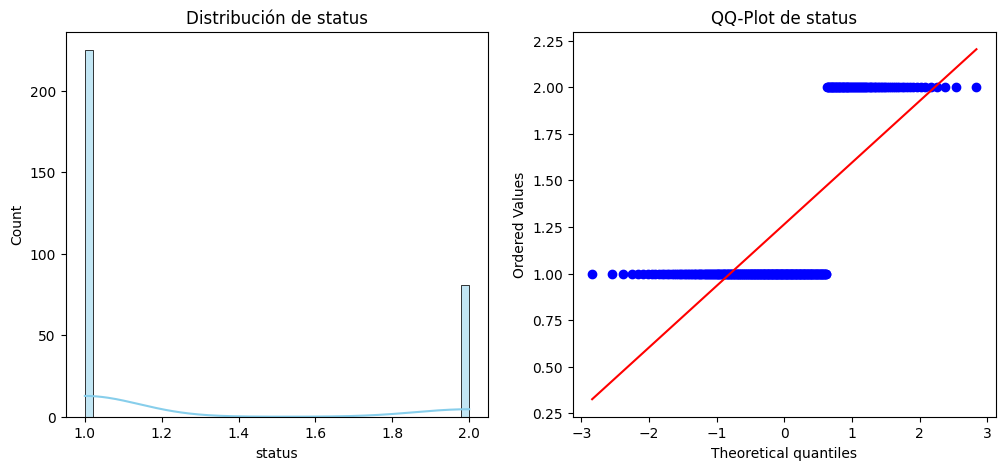


Pruebas de normalidad para la columna: status
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 71.18230
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000


In [52]:
# Función para realizar pruebas de normalidad
def normality_tests(data, column_name):
    print(f"\nPruebas de normalidad para la columna: {column_name}")

    # Prueba de Shapiro-Wilk
    shapiro_test = stats.shapiro(data.sample(min(5000, len(data)), random_state=42))  # Muestra de 5000 para evitar problemas de cómputo
    print(f"Shapiro-Wilk Test: p-valor = {shapiro_test.pvalue:.5f}")

    # Prueba de Kolmogorov-Smirnov
    ks_test = stats.kstest(data, 'norm', args=(data.mean(), data.std()))
    print(f"Kolmogorov-Smirnov Test: p-valor = {ks_test.pvalue:.5f}")

    # Prueba de Anderson-Darling
    anderson_test = stats.anderson(data, dist='norm')
    print(f"Anderson-Darling Test: Estadístico = {anderson_test.statistic:.5f}")
    for i in range(len(anderson_test.critical_values)):
        sl, cv = anderson_test.significance_level[i], anderson_test.critical_values[i]
        if anderson_test.statistic < cv:
            print(f"  Al nivel de significancia {sl}%, los datos parecen normales.")
        else:
            print(f"  Al nivel de significancia {sl}%, los datos NO parecen normales.")

    # Prueba de D'Agostino-Pearson
    dagostino_test = stats.normaltest(data)
    print(f"D'Agostino-Pearson Test: p-valor = {dagostino_test.pvalue:.5f}")

# Función para graficar histograma y QQ-Plot
def plot_distribution(data, column_name):
    plt.figure(figsize=(12, 5))

    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(data, bins=50, kde=True, color="skyblue")
    plt.title(f"Distribución de {column_name}")

    # QQ-Plot
    plt.subplot(1, 2, 2)
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"QQ-Plot de {column_name}")

    plt.show()

# Aplicar pruebas de normalidad y gráficos a cada columna numérica
for column in df.columns:
  print(column)
  data = df[column]
  plot_distribution(data, column)
  normality_tests(data, column)

  * ¿Qué variables no siguen una distribución normal según las pruebas de Shapiro-Wilk, Anderson-Darling y Kolmogorov-Smirnov? ¿Cómo afecta esto al modelo de regresión lineal?
    * *Sólo la variable 'age' parece mostrar una distribución normal según la prueba de Kolmogorov-Smirnov dónde p_value > 0.05, mientras que la prueba de Shapiro-Wilk indica que no es normal y a ciertos niveles de confianza la prueba Anderson-Darling esta última nos dice que los datos son normales.*
    * *Para una regresión lineal, estos datos podrían no tener un buen desempeño a la hora de realizar predicciones por qué los datos no exhiben una distribución normal en la mayoría de sus columnas.*

  * ¿Qué conclusiones puedes extraer de los QQplots? ¿Qué variables tienen una distribución cercana a la normal?
    * ** Sólo la distribución edad muestra un una coincidencia con el diagrama de QQ-plot, nodes tal vez con una alguna transformación podría normalizarse.

# 3. Tratamiento de Datos Faltantes:

In [53]:
df.isna().sum()

,0
age,0
year,0
nodes,0
status,0


  * ¿Qué columnas tenían todos los valores faltantes? ¿Cómo manejaste estas columnas? Para este conjunto de datos, no tenemos valores faltantes. No se realizaron operaciones para tratar datos faltantes.
    * *Para este conjunto de datos no existen datos faltantes.*

  * ¿Cómo cambió el EDA después de la imputación de datos? ¿Observaste diferencias significativas en las distribuciones de las variables?
    * *No se realizaron actividades de imptutación dado que no había valores faltantes.*

# 4. Matriz de Correlación y Pairplot:

<Axes: >

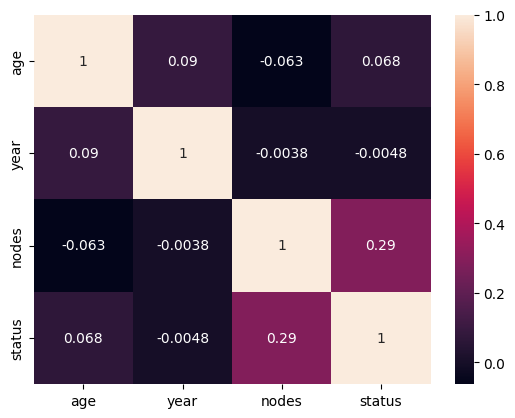

In [54]:
sns.heatmap(df.corr(), annot = True)

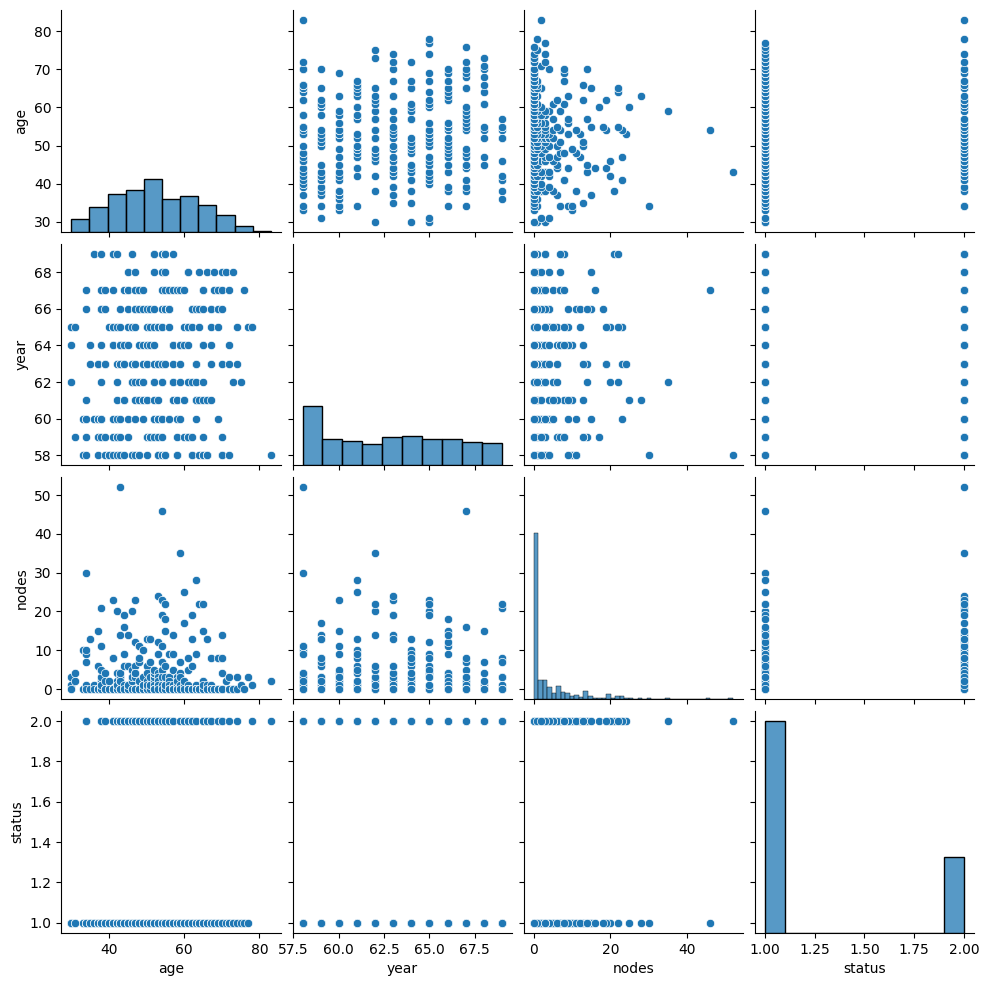

In [56]:
sns.pairplot(df)

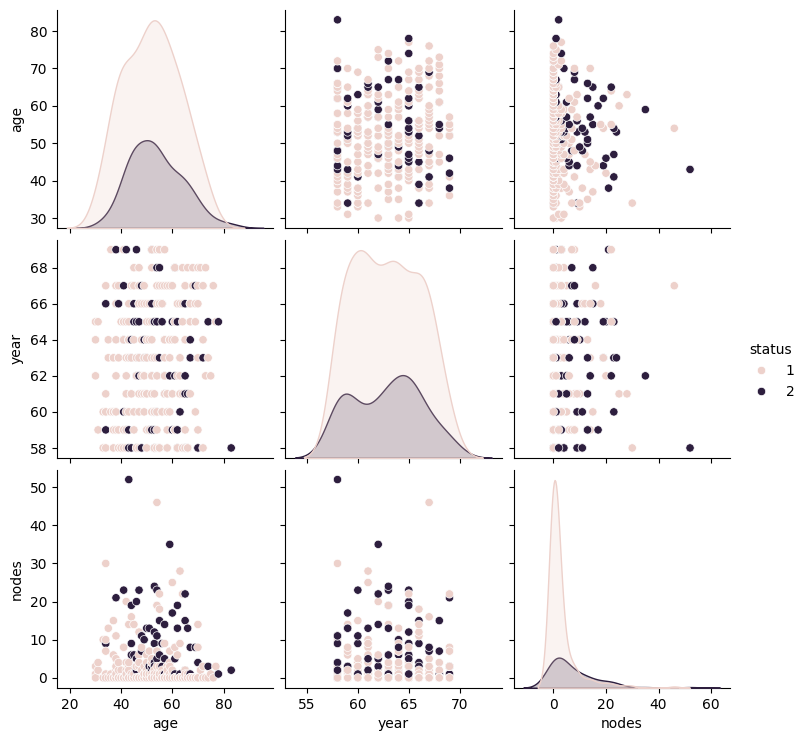

In [57]:
sns.pairplot(df, hue='status')

  * ¿Qué relaciones lineales identificaste en la matriz de correlación y el pairplot? ¿Alguna variable tiene una correlación fuerte con la variable objetivo?
    * *No exhiben relaciones lineales entre variables de este conjunto de datos.*

  * ¿Cómo podrías utilizar esta información para seleccionar características (features) en un modelo de regresión lineal?
    * *Tal vez, sí aplicaramos alguna transformación a los datos y volvieramos a gráficar las distribuciones, podríamos encontrar las correlaciones lineales, en al menos las variables age y nodes.*